# Project 5: neural quantum states for the quantum dot, from the Boltzmann machine to a physics-informed ansatz

Companion notebook to Appendix A, Project 5, of *Quantum mechanics for
many-particle systems*.  The code is the same as in
`BookManybody/BookPrograms/appendixA/nqs.py`, which extends the
`NeuralQuantumState` class of the chapter-17 program `rbm.py` and uses the
blocking of the chapter-14 program `vmcoptimise.py`; the notebook runs it
section by section.

The wave function of two electrons in a two-dimensional harmonic trap at
$\omega=1$ is represented by the square root of the marginal distribution
of a Gaussian-binary restricted Boltzmann machine -- Carleo and Troyer's
*neural quantum state* -- and optimised by variational Monte Carlo.  The
project builds the code in the order of chapters 13, 14 and 17: the
analytic derivatives, brute-force and importance-sampled Metropolis,
gradient descent and stochastic reconfiguration, the blocking analysis,
and finally the interaction, where Taut's exact energy of $3$ a.u. is the
target.  It ends where chapter 18 begins: with the cusp put into the
ansatz by hand.

In [1]:
import sys, os, glob, time
import numpy as np
import matplotlib.pyplot as plt

for _pattern in ("chapter*", "appendix*"):
    for _d in sorted(glob.glob(os.path.join("..", "BookManybody",
                                            "BookPrograms", _pattern))):
        if _d not in sys.path:
            sys.path.insert(0, _d)
import nqs
from vmcoptimise import blocking, blocking_curve

np.set_printoptions(precision=6, suppress=True, linewidth=120)

## 1. The ansatz and its derivatives

With $M=PD$ visible units $x_m$ (the coordinates), $N$ hidden units, and
$Q_n=b_n+\sum_m x_mw_{mn}/\sigma^2$, the neural quantum state of
chapter 17 is

$$
\ln\Psi(\mathbf x)=-\sum_m\frac{(x_m-a_m)^2}{4\sigma^2}
+\frac12\sum_n\ln\!\big(1+e^{Q_n}\big),
$$

the square root of the RBM marginal, so that $|\Psi|^2$ is itself an RBM
distribution.  The local energy needs $\partial_m\ln\Psi$ and
$\partial_m^2\ln\Psi$, and the optimiser needs
$O_k=\partial\ln\Psi/\partial\theta_k$ for every parameter
$\theta=(\mathbf a,\mathbf b,\mathbf W)$ -- and, in this project, also for
the width $\sigma$ and for the parameter $\beta$ of an optional
Padé-Jastrow factor $\exp[r_{12}/(1+\beta r_{12})]$.  Every one of these
is checked against finite differences before anything else is run, and
Taut's exact state is used as the ultimate test of the local energy: its
$E_L$ must be exactly $3$ everywhere.

In [2]:
for key, (dp, de) in nqs.check_derivatives().items():
    print(f"jastrow={key[0]!s:5s} learn_sigma={key[1]!s:5s}: "
          f"max |O_analytic - O_fd| = {dp:.1e}, max |E_L analytic - fd| = {de:.1e}")
e = nqs.taut_local_energy()
print(f"Taut's exact state: E_L = {e.mean():.12f} with spread {e.std():.1e} over {len(e)} random points")
psi = nqs.ProjectNQS(n_hidden=4, jastrow=True, learn_sigma=True)
print("parameters:", psi.n_parameters, "=", ", ".join(psi.parameter_names()[:6]), "...,", ", ".join(psi.parameter_names()[-2:]))

jastrow=False learn_sigma=False: max |O_analytic - O_fd| = 2.5e-10, max |E_L analytic - fd| = 1.1e-07
jastrow=True  learn_sigma=False: max |O_analytic - O_fd| = 2.5e-10, max |E_L analytic - fd| = 1.1e-07
jastrow=True  learn_sigma=True : max |O_analytic - O_fd| = 4.9e-10, max |E_L analytic - fd| = 1.1e-07
Taut's exact state: E_L = 3.000000000000 with spread 4.1e-16 over 2000 random points
parameters: 26 = a0, a1, a2, a3, b0, b1 ..., beta, sigma


## 2. One particle in one dimension, two hidden units

The first calculation is the smallest possible: one particle, one
dimension, no interaction, two hidden units, seven parameters.  The exact
energy is $1/2$.  With $\sigma^2=1/2\omega$ the machine represents the
exact ground state at zero weights, so the optimiser only has to switch
the hidden units off, and the variance of the local energy is a direct
measure of how well it has done so.  We follow the training for three
learning rates.

learning rate 0.01: E = 0.501053 +/- 0.000133, var(E_L) = 2.08e-03   (exact 0.5)


learning rate 0.05: E = 0.500740 +/- 0.000111, var(E_L) = 1.50e-03   (exact 0.5)


learning rate 0.20: E = 0.500284 +/- 0.000070, var(E_L) = 5.97e-04   (exact 0.5)


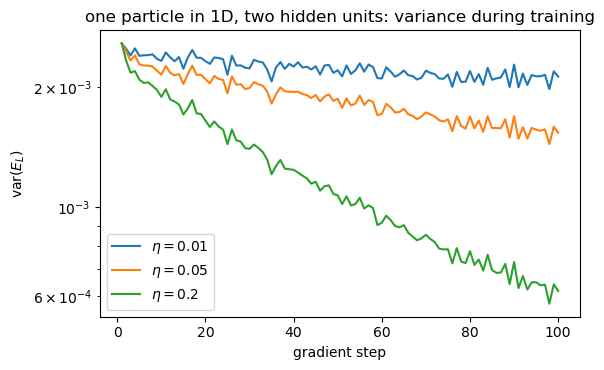

In [3]:
fig, ax = plt.subplots(figsize=(6.0, 3.8))
for rate in (0.01, 0.05, 0.2):
    psi = nqs.ProjectNQS(n_particles=1, n_dimensions=1, n_hidden=2, interaction=False,
                         rng=np.random.default_rng(5), scale=0.3)
    hist = psi.train("sgd", learning_rate=rate, max_iter=100, n_cycles=200, n_walkers=100)
    prod = psi.production(n_cycles=2000, n_walkers=200)
    print(f"learning rate {rate:4.2f}: E = {prod['energy']:.6f} +/- {prod['error']:.6f}, "
          f"var(E_L) = {prod['variance']:.2e}   (exact 0.5)")
    ax.semilogy([h[0] for h in hist], [h[2] for h in hist], label=rf"$\eta={rate}$")
ax.set_xlabel("gradient step")
ax.set_ylabel(r"$\mathrm{var}(E_L)$")
ax.set_title("one particle in 1D, two hidden units: variance during training")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Sampling: brute force against importance sampling

The samplers of chapter 13 are both implemented for the machine: a
symmetric uniform step of size $\Delta$ accepted with $|\Psi'/\Psi|^2$, and
the Langevin move with the quantum force $\mathbf F=2\nabla\ln\Psi$ and
time step $\delta t$ accepted with the Metropolis-Hastings ratio.  We train
one interacting machine ($N=4$ hidden units) and then compare the two
samplers on it: the acceptance rate, and -- the quantity that matters --
the statistical error of the energy from the blocking analysis of
chapter 14 for the same number of Monte Carlo cycles.

In [4]:
machine = nqs.ProjectNQS(n_hidden=4, rng=np.random.default_rng(11))
t0 = time.time()
hist_sgd = machine.train("sgd", learning_rate=0.05, max_iter=120, n_cycles=300, n_walkers=200)
print(f"trained in {time.time() - t0:.0f} s; last energy estimate {hist_sgd[-1][1]:.5f}")
theta_sgd = machine.get_theta().copy()

rows = []
print(f"{'sampler':>12s} {'step':>6s} {'acceptance':>11s} {'E':>10s} {'error':>9s} {'var(E_L)':>9s}")
for step in (0.25, 0.5, 1.0, 2.0):
    r = machine.production(n_cycles=2000, n_walkers=200, sampler="brute", step=step)
    rows.append(("brute force", step, r["acceptance"], r["energy"], r["error"], r["variance"], r["samples"]))
    print(f"{'brute force':>12s} {step:6.2f} {r['acceptance']:11.3f} {r['energy']:10.5f} {r['error']:9.5f} {r['variance']:9.3f}")
for dt in (0.02, 0.1, 0.5, 2.0):
    r = machine.production(n_cycles=2000, n_walkers=200, sampler="importance", time_step=dt)
    rows.append(("importance", dt, r["acceptance"], r["energy"], r["error"], r["variance"], r["samples"]))
    print(f"{'importance':>12s} {dt:6.2f} {r['acceptance']:11.3f} {r['energy']:10.5f} {r['error']:9.5f} {r['variance']:9.3f}")

trained in 19 s; last energy estimate 3.20245
     sampler   step  acceptance          E     error  var(E_L)


 brute force   0.25       0.894    3.22051   0.00837    10.132


 brute force   0.50       0.791    3.20645   0.00593     3.794


 brute force   1.00       0.601    3.21040   0.00556     4.056


 brute force   2.00       0.324    3.21186   0.00634     3.755


  importance   0.02       0.999    3.20480   0.00790     3.727


  importance   0.10       0.989    3.20424   0.00426     2.940


  importance   0.50       0.882    3.20750   0.00432     3.597


  importance   2.00       0.312    3.20622   0.00690     3.353


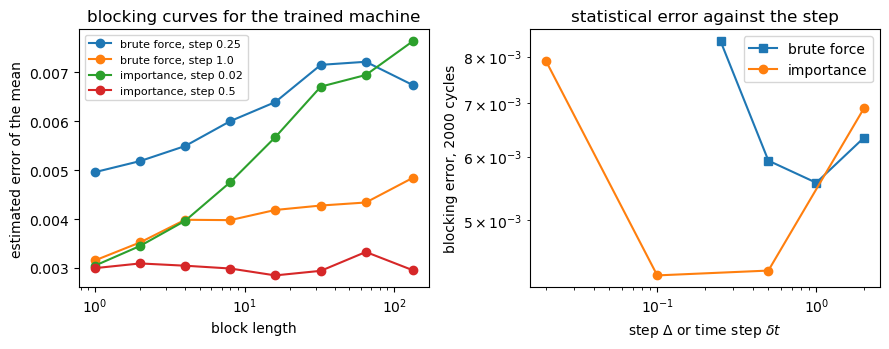

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(9.0, 3.6))
for name, step, acc, E, err, var, samples in rows:
    if (name == "brute force" and step in (0.25, 1.0)) or (name == "importance" and step in (0.02, 0.5)):
        curve = np.array(blocking_curve(samples))
        axes[0].semilogx(len(samples) / curve[:, 0], curve[:, 1], "o-",
                         label=f"{name}, step {step}")
axes[0].set_xlabel("block length")
axes[0].set_ylabel("estimated error of the mean")
axes[0].set_title("blocking curves for the trained machine")
axes[0].legend(fontsize=8)
for name, marker in (("brute force", "s"), ("importance", "o")):
    sel = [(step, err) for n, step, acc, E, err, var, s in rows if n == name]
    axes[1].loglog([s for s, _ in sel], [e for _, e in sel], marker + "-", label=name)
axes[1].set_xlabel(r"step $\Delta$ or time step $\delta t$")
axes[1].set_ylabel("blocking error, 2000 cycles")
axes[1].set_title("statistical error against the step")
axes[1].legend()
plt.tight_layout()
plt.show()

Both samplers give the same energy within the error, as they must -- they
sample the same $|\Psi|^2$ -- but not with the same efficiency.  The
brute-force walk has a best step, where the acceptance is around one half;
the importance-sampled walk keeps its acceptance near one and its error
smaller over a wide range of time steps, because the drift term moves the
walkers where the wave function is large instead of waiting for them to
diffuse there.  The blocking curves show the same thing: the plateau is
reached after fewer transformations, so the correlation time is shorter.

## 4. Optimisation: gradient descent against stochastic reconfiguration

The gradient of the energy is the covariance of chapter 14,
$\partial_kE=2\big(\langle E_LO_k\rangle-\langle E_L\rangle\langle O_k\rangle\big)$.
Plain gradient descent moves along it; stochastic reconfiguration
preconditions it with the metric
$S_{kl}=\langle O_kO_l\rangle-\langle O_k\rangle\langle O_l\rangle$,
regularised by a diagonal shift, which makes the step independent of the
scaling of the parameters -- and with $24$ parameters of very different
sensitivities that matters.  We run both from the same start on the
interacting dot, and add a third run in which the width $\sigma$ is
promoted to a variational parameter.

SGD, $\eta=0.05$      : E = 3.20826 +/- 0.00207, var(E_L) = 4.520, sigma = 0.7071


SR, $\eta=0.2$        : E = 3.06537 +/- 0.00169, var(E_L) = 3.130, sigma = 0.7071


SR, $\sigma$ learned  : E = 3.04697 +/- 0.00133, var(E_L) = 1.893, sigma = 0.6128


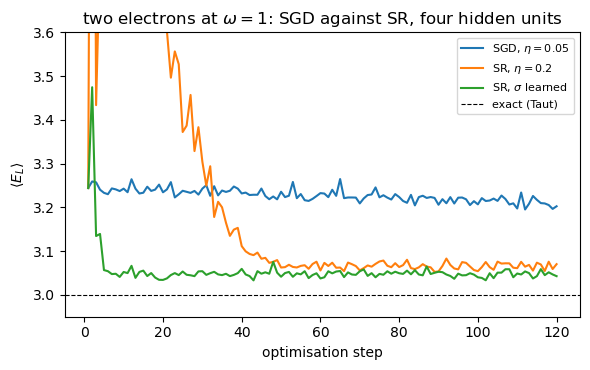

In [6]:
runs = {}
fig, ax = plt.subplots(figsize=(6.0, 3.8))
for label, kwargs, method, rate in (("SGD, $\\eta=0.05$", dict(n_hidden=4), "sgd", 0.05),
                                   ("SR, $\\eta=0.2$", dict(n_hidden=4), "sr", 0.2),
                                   ("SR, $\\sigma$ learned", dict(n_hidden=4, learn_sigma=True), "sr", 0.2)):
    psi = nqs.ProjectNQS(rng=np.random.default_rng(11), **kwargs)
    hist = psi.train(method, learning_rate=rate, max_iter=120, n_cycles=300, n_walkers=200)
    prod = psi.production()
    runs[label] = (psi, hist, prod)
    print(f"{label:22s}: E = {prod['energy']:.5f} +/- {prod['error']:.5f}, var(E_L) = {prod['variance']:.3f}, "
          f"sigma = {psi.sigma:.4f}")
    ax.plot([h[0] for h in hist], [h[1] for h in hist], label=label)
ax.axhline(3.0, color="k", ls="--", lw=0.8, label="exact (Taut)")
ax.set_ylim(2.95, 3.6)
ax.set_xlabel("optimisation step")
ax.set_ylabel(r"$\langle E_L\rangle$")
ax.set_title("two electrons at $\\omega=1$: SGD against SR, four hidden units")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

Stochastic reconfiguration reaches in a few tens of steps what gradient
descent does not reach in a hundred, and settles lower: the natural
gradient knows that a change of a hidden bias and a change of a weight
are not the same size of step on the manifold of wave functions.  Learning
$\sigma$ helps a little more -- the interacting state is broader than the
non-interacting one that fixed $\sigma^2=1/2\omega$ -- but the energy stays
several hundredths above $3$, and the variance of the local energy stays
of order one.  Chapter 17 identified the reason: nothing in a Gaussian
times a product of sigmoids can produce the cusp at $r_{12}=0$.

## 5. The cusp

The cheapest physics-informed ansatz multiplies the machine by the
Padé-Jastrow factor of chapter 13,

$$
\Psi(\mathbf x)=\Psi_{\rm RBM}(\mathbf x)\,\exp\!\Big(\frac{r_{12}}{1+\beta r_{12}}\Big),
$$

whose unit slope at the origin cancels the $1/r_{12}$ of the Hamiltonian
exactly, with $\beta$ as one more variational parameter.  The hidden
units are then left with what the rational function gets wrong further
out -- the difference between $\ln(1+r_{12})$ and $r_{12}/(1+\beta r_{12})$
that chapter 18 drew -- which is a smooth, bounded function they can
represent.

RBM x Jastrow, SR: E = 3.000031 +/- 0.000018, var(E_L) = 0.00030, beta = 0.4548


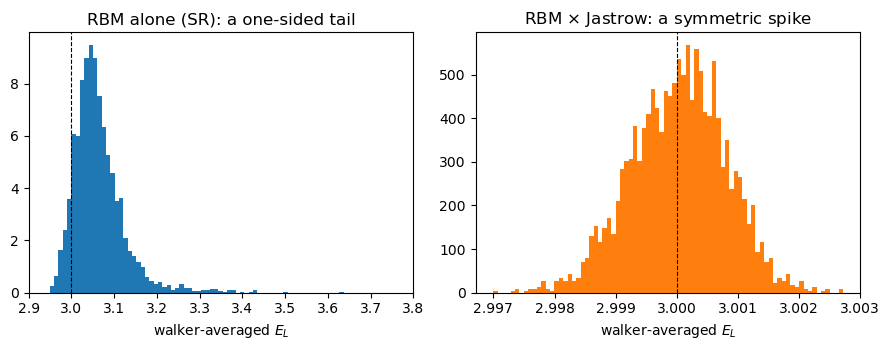

In [7]:
psi_j = nqs.ProjectNQS(n_hidden=4, jastrow=True, rng=np.random.default_rng(11))
hist_j = psi_j.train("sr", learning_rate=0.2, max_iter=120, n_cycles=300, n_walkers=200)
prod_j = psi_j.production()
print(f"RBM x Jastrow, SR: E = {prod_j['energy']:.6f} +/- {prod_j['error']:.6f}, "
      f"var(E_L) = {prod_j['variance']:.5f}, beta = {psi_j.beta:.4f}")

# the local-energy distributions with and without the cusp
prod_sr = runs["SR, $\\eta=0.2$"][2]
fig, axes = plt.subplots(1, 2, figsize=(9.0, 3.6))
axes[0].hist(prod_sr["samples"], bins=200, density=True, color="C0")
axes[0].axvline(3.0, color="k", ls="--", lw=0.8)
axes[0].set_xlim(2.9, 3.8)                    # a few far outliers are cut off
axes[0].set_xlabel(r"walker-averaged $E_L$")
axes[0].set_title("RBM alone (SR): a one-sided tail")
axes[1].hist(prod_j["samples"], bins=80, density=True, color="C1")
axes[1].axvline(3.0, color="k", ls="--", lw=0.8)
axes[1].set_xlabel(r"walker-averaged $E_L$")
axes[1].set_title(r"RBM $\times$ Jastrow: a symmetric spike")
plt.tight_layout()
plt.show()

With the cusp in place the same machine, the same optimiser and the same
number of samples give the exact energy to a few parts in $10^5$ with a
variance ten thousand times smaller.  Set beside the other trial functions
of the book for the same system:

In [8]:
print(f"{'trial function':40s} {'E':>12s} {'var(E_L)':>10s} {'E - 3':>10s}")
table = [("RBM, N=4, SGD (this project)", runs["SGD, $\\eta=0.05$"][2]),
         ("RBM, N=4, SR (this project)", runs["SR, $\\eta=0.2$"][2]),
         ("RBM, N=4, SR, sigma learned", runs["SR, $\\sigma$ learned"][2]),
         ("RBM, N=4 x Pade-Jastrow, SR", prod_j)]
for name, p in table:
    print(f"{name:40s} {p['energy']:12.6f} {p['variance']:10.5f} {p['energy'] - 3:+10.5f}")
print(f"{'Pade-Jastrow, 2 parameters (chapter 13)':40s} {3.001323:12.6f} {0.0054:10.5f} {0.001323:+10.5f}")
print(f"{'Pade-Jastrow x neural correlator (ch. 18)':40s} {3.000477:12.6f} {0.0027:10.5f} {0.000477:+10.5f}")
print(f"{'exact (Taut)':40s} {3.0:12.6f} {0.0:10.5f} {0.0:+10.5f}")

trial function                                      E   var(E_L)      E - 3
RBM, N=4, SGD (this project)                 3.208257    4.52009   +0.20826
RBM, N=4, SR (this project)                  3.065366    3.12955   +0.06537
RBM, N=4, SR, sigma learned                  3.046974    1.89276   +0.04697
RBM, N=4 x Pade-Jastrow, SR                  3.000031    0.00030   +0.00003
Pade-Jastrow, 2 parameters (chapter 13)      3.001323    0.00540   +0.00132
Pade-Jastrow x neural correlator (ch. 18)     3.000477    0.00270   +0.00048
exact (Taut)                                 3.000000    0.00000   +0.00000


## Summary

The project passes through every stage of a variational Monte Carlo
calculation with a learned wave function: analytic derivatives checked
against finite differences and against an exact state, two samplers
compared by their blocking errors, two optimisers compared on the same
gradient, and the ansatz itself examined through the variance of the
local energy.  The result is the lesson of chapters 17 and 18 in one
table: a machine with no physics in it beats the mean field; a machine
with one line of physics -- the cusp -- beats everything else in the book
on this system.